# Image Augmentation Workbench

This notebook creates a separate augmented dataset for the classification workshop.

We will:
- load the source images,
- inspect current class imbalance,
- preview realistic augmentations,
- generate extra images for smaller classes,
- export the result to a new folder with a metadata file.

The notebook respects the active training goal:
- `device_type` augments only the clean device folders used for training.
- `damage_status` augments both `Damaged` and `Not-Damaged` examples when class balancing calls for it. In that mode, augmented clean device images are valid extra `Not-Damaged` examples.


## 1. Imports and helpers

This notebook uses the same shared workshop utilities as the classification notebook so the workflow stays consistent.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    compute_balanced_targets,
    export_augmented_dataset,
    load_image_records,
    preview_augmentations,
    record_timing,
    target_column_for_mode,
    timing_frame,
    validate_target_mode,
)

step_timings = []

## 2. Configuration

Change these values to control where images come from and where augmented copies should be saved.


In [2]:
SOURCE_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Device_Images_Nelson").resolve()
SOURCE_METADATA_PATH = SOURCE_DATASET_ROOT / "metadata.csv"
OUTPUT_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
TARGET_MODE = "damage_status"  # Change to "device_type" to train on device types instead of damage status.
INCLUDED_DEVICE_TYPES = ["device1", "device 2"]
OUTPUT_IMAGE_SIZE = 224
RANDOM_SEED = 42
TARGET_CLASS_SIZE = 40  # None means match the size of the largest class.

print(f"Source dataset: {SOURCE_DATASET_ROOT}")
print(f"Output dataset: {OUTPUT_DATASET_ROOT}")
print(f"Target mode: {TARGET_MODE}")
print(f"Included device folders: {INCLUDED_DEVICE_TYPES}")


Source dataset: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Device_Images_Nelson
Output dataset: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Target mode: damage_status
Included device folders: ['device1', 'device 2']


## 3. Load source records and inspect imbalance

Before generating data, we should measure the problem we are trying to solve.


Loaded 52 records in 0.00 seconds before workshop filtering
Standard device records after included-device filtering: 8
Defect records available: 17
Damage-status note: augmented clean device images will serve as extra `Not-Damaged` samples.


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/2.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/2_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/3.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False


Target `damage_status` is ready with classes: ['Damaged', 'Not-Damaged']


,count
damage_status,
Damaged,17
Not-Damaged,8


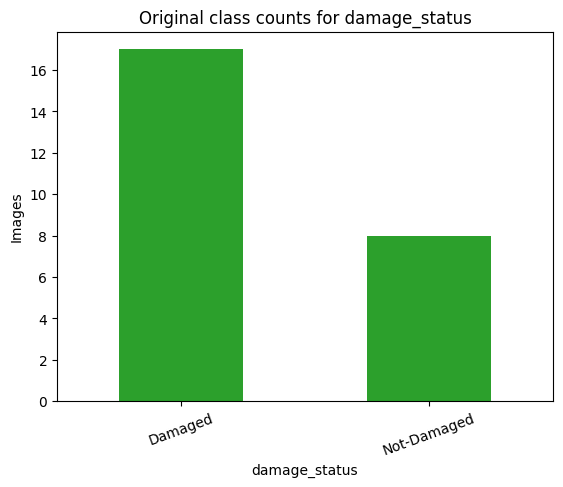

In [3]:
started = time.perf_counter()
all_records = load_image_records(
    SOURCE_DATASET_ROOT,
    metadata_path=SOURCE_METADATA_PATH if SOURCE_METADATA_PATH.exists() else None,
)
scan_elapsed = record_timing(step_timings, "dataset_scan", started)

print(f"Loaded {len(all_records)} records in {scan_elapsed:.2f} seconds before workshop filtering")

standard_device_records = all_records[all_records["is_standard_device_image"]].reset_index(drop=True)
standard_device_records = standard_device_records[standard_device_records["device_type"].isin(INCLUDED_DEVICE_TYPES)].reset_index(drop=True)
defect_records = all_records[all_records["is_defect_challenge"]].reset_index(drop=True)

print(f"Standard device records after included-device filtering: {len(standard_device_records)}")
print(f"Defect records available: {len(defect_records)}")

if TARGET_MODE == "device_type":
    records = standard_device_records.copy()
    print("Defect images are excluded from augmentation so they cannot leak into device-type training.")
else:
    records = pd.concat([standard_device_records, defect_records], ignore_index=True)
    print("Damage-status note: augmented clean device images will serve as extra `Not-Damaged` samples.")

display(records.head())

is_valid_target, target_message = validate_target_mode(records, TARGET_MODE)
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

target_column = target_column_for_mode(TARGET_MODE)
records = records[records[target_column].notna()].reset_index(drop=True)
class_counts = records[target_column].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())
class_counts.plot(kind="bar", color="#2ca02c", title=f"Original class counts for {TARGET_MODE}")
plt.ylabel("Images")
plt.xticks(rotation=20)
plt.show()


## 4. Preview augmentation ideas

We want realistic variation, not nonsense. Use this preview to judge whether the transformations still look believable for your inspection task.

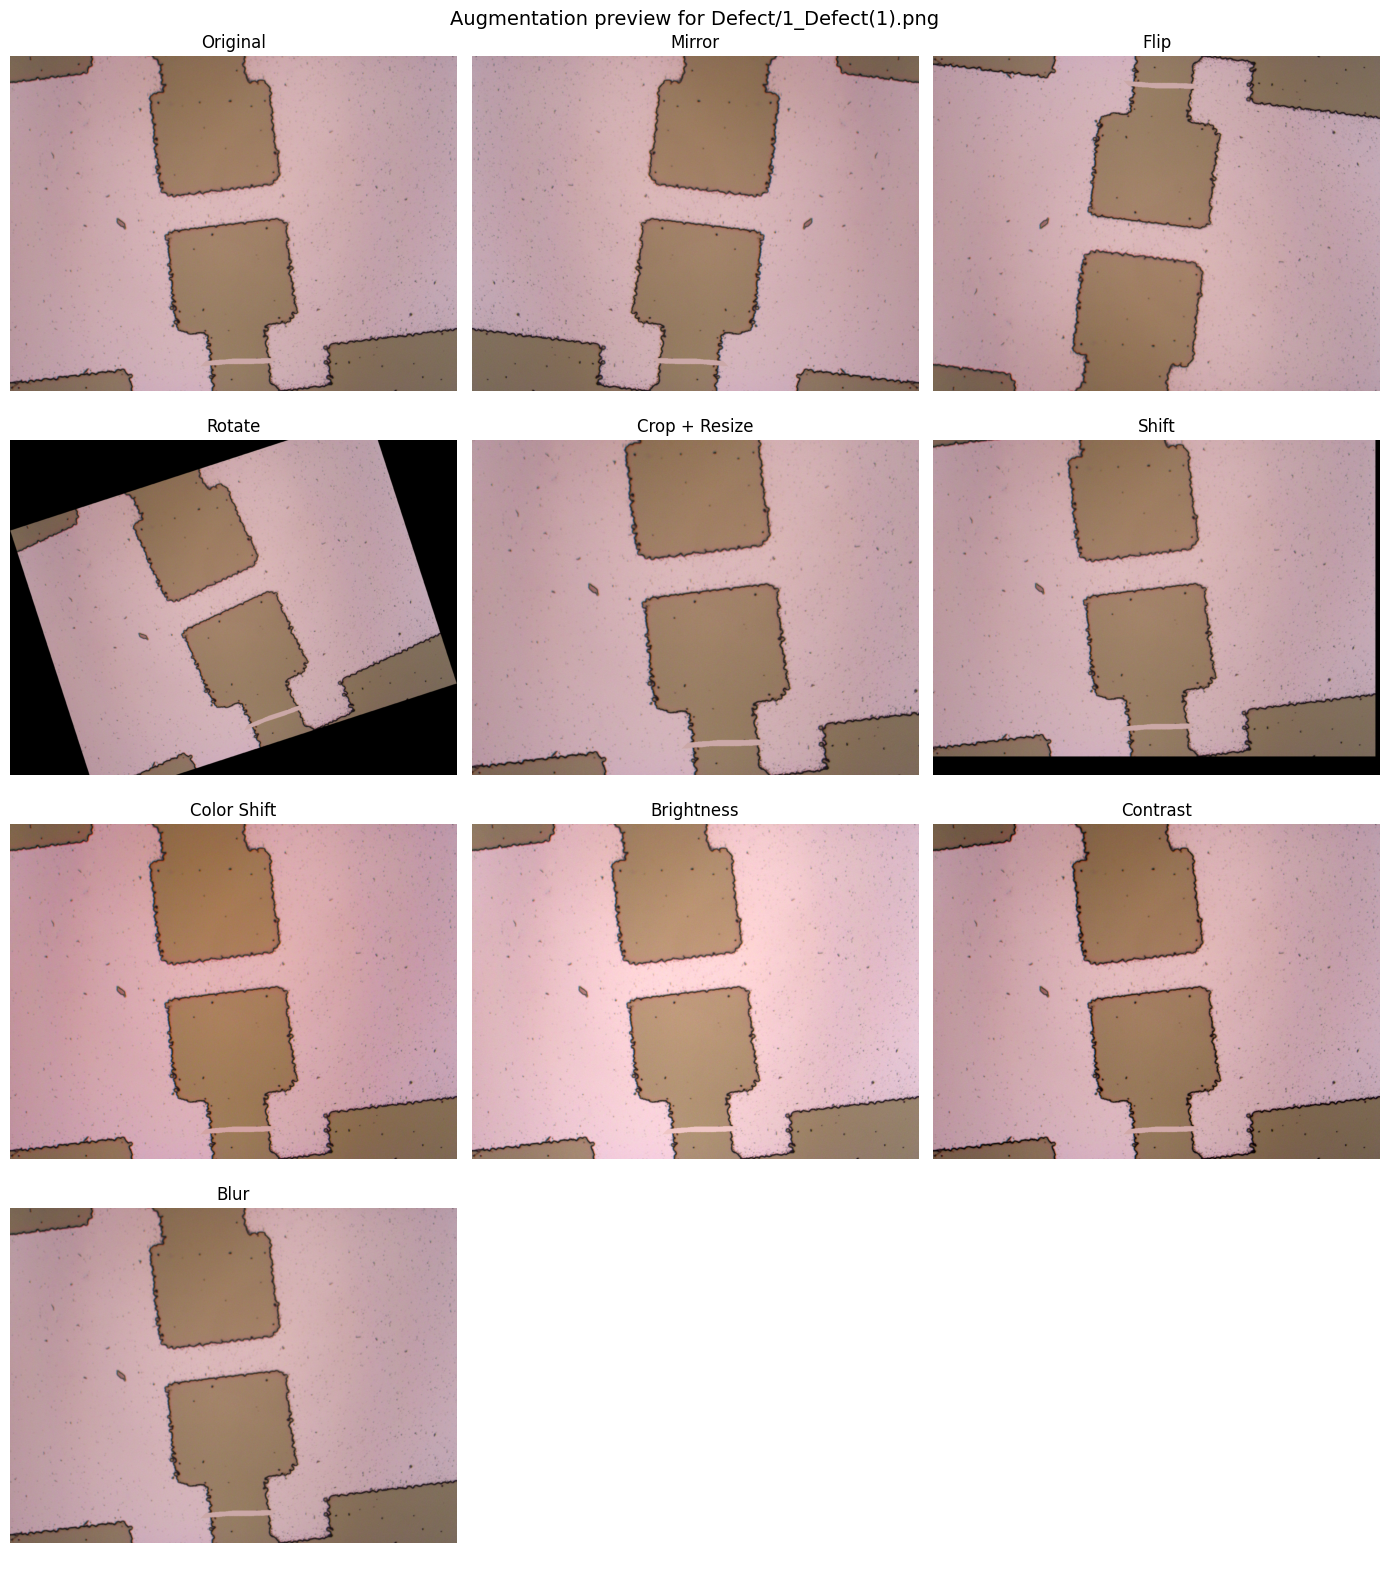

In [4]:
preview_row = records.sample(1, random_state=RANDOM_SEED).iloc[0]
with Image.open(preview_row["filepath"]) as image:
    preview_images = preview_augmentations(image, seed=RANDOM_SEED)

preview_items = list(preview_images.items())
columns = 3
rows = (len(preview_items) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(14, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes:
    ax.axis("off")

for ax, (title, aug_image) in zip(axes, preview_items):
    ax.imshow(aug_image)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"Augmentation preview for {preview_row['relative_path']}", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Decide how many new images to create

By default, this notebook balances the classes by adding more images to the smaller classes.
In `damage_status` mode, this plan is a binary-class plan: extra clean device images count only toward `Not-Damaged`, and extra defect images count toward `Damaged`.


In [5]:
augmentation_plan = compute_balanced_targets(
    records,
    label_column=target_column,
    target_class_size=TARGET_CLASS_SIZE,
)
plan_frame = pd.DataFrame(
    {
        "current_count": class_counts,
        "new_images_needed": pd.Series(augmentation_plan),
    }
).fillna(0).astype(int)
plan_frame["projected_total"] = plan_frame["current_count"] + plan_frame["new_images_needed"]
display(plan_frame)

if TARGET_MODE == "damage_status":
    print("Damage-status augmentation check:")
    print("`Not-Damaged` includes clean device images from the included device folders.")
    print("`Damaged` includes defect images from the `Defect` folder.")
    display(plan_frame.loc[[label for label in ["Damaged", "Not-Damaged"] if label in plan_frame.index]])


,current_count,new_images_needed,projected_total
Damaged,17,23,40
Not-Damaged,8,32,40


Damage-status augmentation check:
`Not-Damaged` includes clean device images from the included device folders.
`Damaged` includes defect images from the `Defect` folder.


,current_count,new_images_needed,projected_total
Damaged,17,23,40
Not-Damaged,8,32,40


## 6. Export the augmented dataset

This cell may take a while. Watch the progress bar and status text. The notebook should show active progress while images are being copied and generated.


In [6]:
started = time.perf_counter()
exported_records = export_augmented_dataset(
    records,
    output_root=OUTPUT_DATASET_ROOT,
    label_column=target_column,
    target_class_size=TARGET_CLASS_SIZE,
    seed=RANDOM_SEED,
    out_size=OUTPUT_IMAGE_SIZE,
    status_prefix="Augment",
)
export_elapsed = record_timing(step_timings, "augmentation_export", started)

print(f"Augmented dataset exported in {export_elapsed:.2f} seconds")
print(f"Metadata written to: {OUTPUT_DATASET_ROOT / 'metadata.csv'}")
if TARGET_MODE == "device_type":
    leaked_defect_rows = int(exported_records["is_defect_folder"].fillna(False).sum())
    print(f"Defect rows exported for device_type mode: {leaked_defect_rows}")
display(exported_records.head())

Augmented dataset exported in 7.48 seconds
Metadata written to: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images\metadata.csv


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge,is_augmented,source_relative_path
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/1.png
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/1_1.png
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/2.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/2.png
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/2_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/2_1.png
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/3.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False,False,device 2/3.png


## 7. Verify the result

We should always confirm that the export actually improved class balance and preserved label information.


,before_export,after_export,added
damage_status,,,
Damaged,17,40,23
Not-Damaged,8,40,32


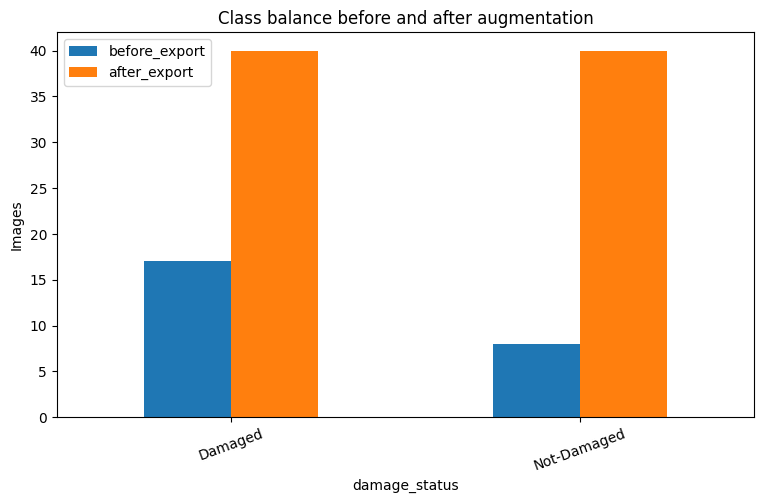

Damage-status labels in exported dataset:


,count
damage_status,
Damaged,40
Not-Damaged,40


Verification note: augmented clean device images remain valid `Not-Damaged` samples in the exported binary dataset.


In [7]:
post_counts = exported_records[target_column].value_counts(dropna=True).sort_index()
verification = pd.DataFrame(
    {
        "before_export": class_counts,
        "after_export": post_counts,
    }
).fillna(0).astype(int)
verification["added"] = verification["after_export"] - verification["before_export"]
display(verification)

verification[["before_export", "after_export"]].plot(kind="bar", figsize=(9, 5), title="Class balance before and after augmentation")
plt.ylabel("Images")
plt.xticks(rotation=20)
plt.show()

if TARGET_MODE == "device_type":
    leaked_defect_rows = int(exported_records["is_defect_folder"].fillna(False).sum())
    if leaked_defect_rows != 0:
        raise ValueError(f"Expected zero defect rows in device_type export, found {leaked_defect_rows}.")
    print("Verified: no defect images were exported into the device_type training dataset.")
else:
    damage_counts = exported_records["damage_status"].value_counts(dropna=True).sort_index()
    print("Damage-status labels in exported dataset:")
    display(damage_counts.rename("count").to_frame())
    print("Verification note: augmented clean device images remain valid `Not-Damaged` samples in the exported binary dataset.")


## 8. Runtime summary

Runtime tracking helps students know the notebook is active and also shows which steps cost the most time.

In [8]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

,step,seconds
0,dataset_scan,0.004
1,augmentation_export,7.477


## 9. Next step

This export also excludes `device 3` by default, so it stays consistent with the classification notebook.

Point the classification notebook to `OUTPUT_DATASET_ROOT` when you want to train on the larger exported dataset.
If you switch that notebook to `TARGET_MODE = "damage_status"`, the augmented clean device images will be used as extra `Not-Damaged` examples.
